In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib
df = pd.read_csv("../data/raw/AMZN.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

# Ensure numeric types
cols = ["Open", "High", "Low", "Close", "Volume"]
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")

# Handle missing values
df = df.dropna()

df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.718,2.7265,2.5535,2.5675,145928000
1,2009-01-05,2.703,2.7870,2.6515,2.7865,190196000
2,2009-01-06,2.868,2.9110,2.6875,2.7275,221602000
3,2009-01-07,2.810,2.8475,2.7675,2.8145,158854000
4,2009-01-08,2.858,2.8660,2.7290,2.7495,131558000


## 📈 Simple Moving Average (SMA)

In [2]:
df["SMA_20"] = talib.SMA(df["Close"], timeperiod=20)
df["SMA_50"] = talib.SMA(df["Close"], timeperiod=50)

## 📈 Exponential Moving Average (EMA)

In [3]:
df["EMA_20"] = talib.EMA(df["Close"], timeperiod=20)

## 📊 Relative Strength Index (RSI)

In [11]:
df["RSI"] = talib.RSI(df["Close"], timeperiod=14)

## 📉 MACD (Momentum indicator)

In [4]:
macd, signal, hist = talib.MACD(df["Close"],
                               fastperiod=12,
                               slowperiod=26,
                               signalperiod=9)

df["MACD"] = macd
df["MACD_Signal"] = signal
df["MACD_Hist"] = hist

## Financial Metrics
Daily Returns

In [6]:
df["Returns"] = df["Close"].pct_change()

## Volatility

In [7]:
volatility = df["Returns"].std() * np.sqrt(252)
print("Annualized Volatility:", volatility)

Annualized Volatility: 0.346527589575433


## Cumulative Returns

In [12]:
df["Cumulative_Return"] = (1 + df["Returns"]).cumprod()

## 📈Visualization

## Price + Moving Averages

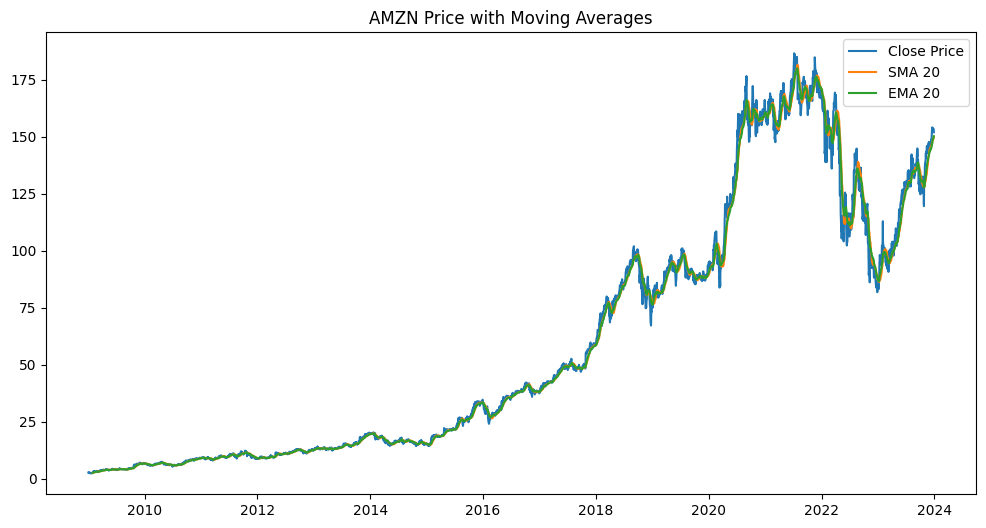

In [9]:
plt.figure(figsize=(12,6))
plt.plot(df["Date"], df["Close"], label="Close Price")
plt.plot(df["Date"], df["SMA_20"], label="SMA 20")
plt.plot(df["Date"], df["EMA_20"], label="EMA 20")

plt.title("AMZN Price with Moving Averages")
plt.legend()
plt.show()

## RSI Plot

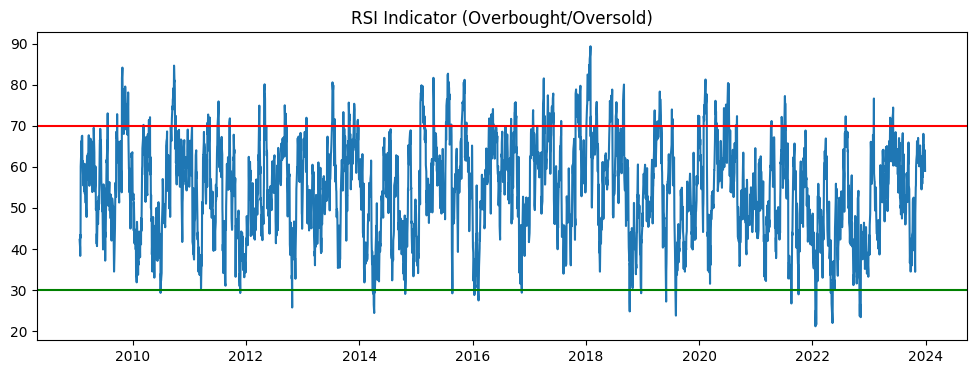

In [13]:
plt.figure(figsize=(12,4))
plt.plot(df["Date"], df["RSI"])
plt.axhline(70, color="red")
plt.axhline(30, color="green")

plt.title("RSI Indicator (Overbought/Oversold)")
plt.show()

## MACD Plot

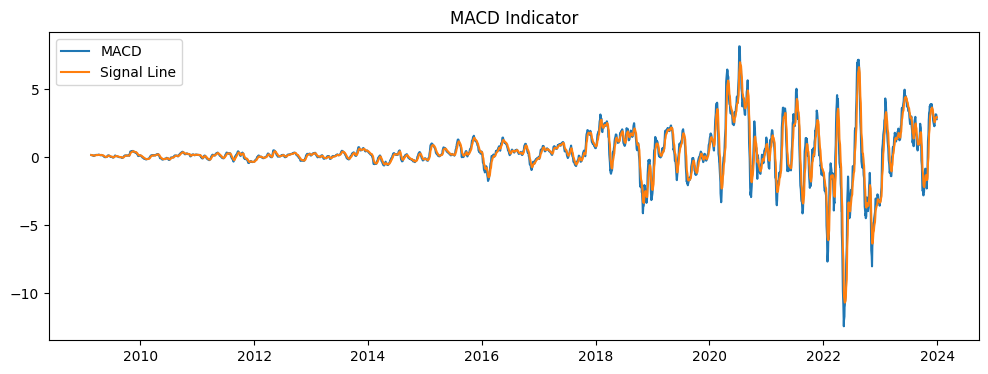

In [14]:
plt.figure(figsize=(12,4))
plt.plot(df["Date"], df["MACD"], label="MACD")
plt.plot(df["Date"], df["MACD_Signal"], label="Signal Line")

plt.legend()
plt.title("MACD Indicator")
plt.show()

## 📊 Task 2: Technical Analysis Summary

---

### 📁 Data Preparation

- Loaded historical stock price data from CSV files  
- Converted `Date` column to `datetime` format for time-series consistency  
- Ensured correct numeric types for OHLCV columns (Open, High, Low, Close, Volume)  
- Handled missing values using `dropna()` and forward fill (`ffill`) where appropriate  

---

### 📈 Indicators Computed

- **Simple Moving Average (SMA):** 20-day and 50-day windows  
- **Exponential Moving Average (EMA):** 20-day and 50-day windows  
- **Relative Strength Index (RSI):** 14-period momentum indicator  
- **MACD (Moving Average Convergence Divergence):** parameters (12, 26, 9)  
- **Returns & Volatility (PyNance):**
  - Daily returns computed using percentage change  
  - 20-day rolling volatility calculated for risk analysis  

---

### 📉 Observations

- RSI spikes were associated with short-term **price reversals**, indicating overbought and oversold conditions  
- MACD line crossovers with the signal line aligned with **trend changes and momentum shifts**  
- SMA (50) frequently acted as a **support/resistance level** during trending market phases  